In [1]:
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('future.no_silent_downcasting', True)

import numpy as np
from laparoscopy_helpers.data_cleaning import (
    to_snake_case, clean_surgical_df
)

In [2]:
os.listdir("../Nkhoma_data")

['Inpatient list Surgery',
 'Poor Patient Funds',
 'Data',
 'Volunteer Agreement',
 'ICU_research.xlsx',
 '.ipynb_checkpoints',
 'laparoscopy_analysed.xlsx',
 'laparoscopy_surgery_mapping.xlsx']

In [3]:
mapping = pd.read_excel("../Nkhoma_data/laparoscopy_surgery_mapping.xlsx")

In [4]:
df = pd.read_excel("../Nkhoma_data/laparoscopy_analysed.xlsx")

/home/mat2m10/.pyenv/versions/3.12.9/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [5]:
df = clean_surgical_df(df, mapping)

In [6]:
# Core patient demographics
df_patient = df[['hospital_number', 'name', 'village_of_residence', 'sex', 'age_at_surgery', 'age_group','weight_kg']]

# Admission and stay
df_admission = df[['hospital_number', 'ward', 'date_of_admission', 'date_of_discharge', 'length_of_hospital_stay_days', 'previous_abdominal_surgery_yes_no']]

# Surgery details
df_surgery = df[['hospital_number', 'date_of_surgery', 'type_of_surgery', 'surgery_type', 'urgency', 'indication', 'duration_mins', 'amount_of_gas_used_l', 'muscle_relaxant_used']]

# Surgical team
df_team = df[['hospital_number', 'attending_surgeon_1', 'attending_surgeon_2', 'resident_surgeon_1', 'resident_surgeon_2', 'teaching']]

# Conversion
df_conversion = df[['hospital_number', 'conversion', 'reason_of_conversion', 'time_of_conversion_min_after_incision']]

# Complications
df_complications = df[['hospital_number', 'complication', 'complication_clavien_dindo', 'complication_description']]

# Payment
df_payment = df[['hospital_number', 'payment_method_scheme_cash', 'cost_mwk', 'patientpayment_mwk', 'other_payment_source']]

# Age

In [7]:
df["urgency"].value_counts(dropna=False)

urgency
Elective     79
Emergency    21
Urgent        4
Name: count, dtype: int64

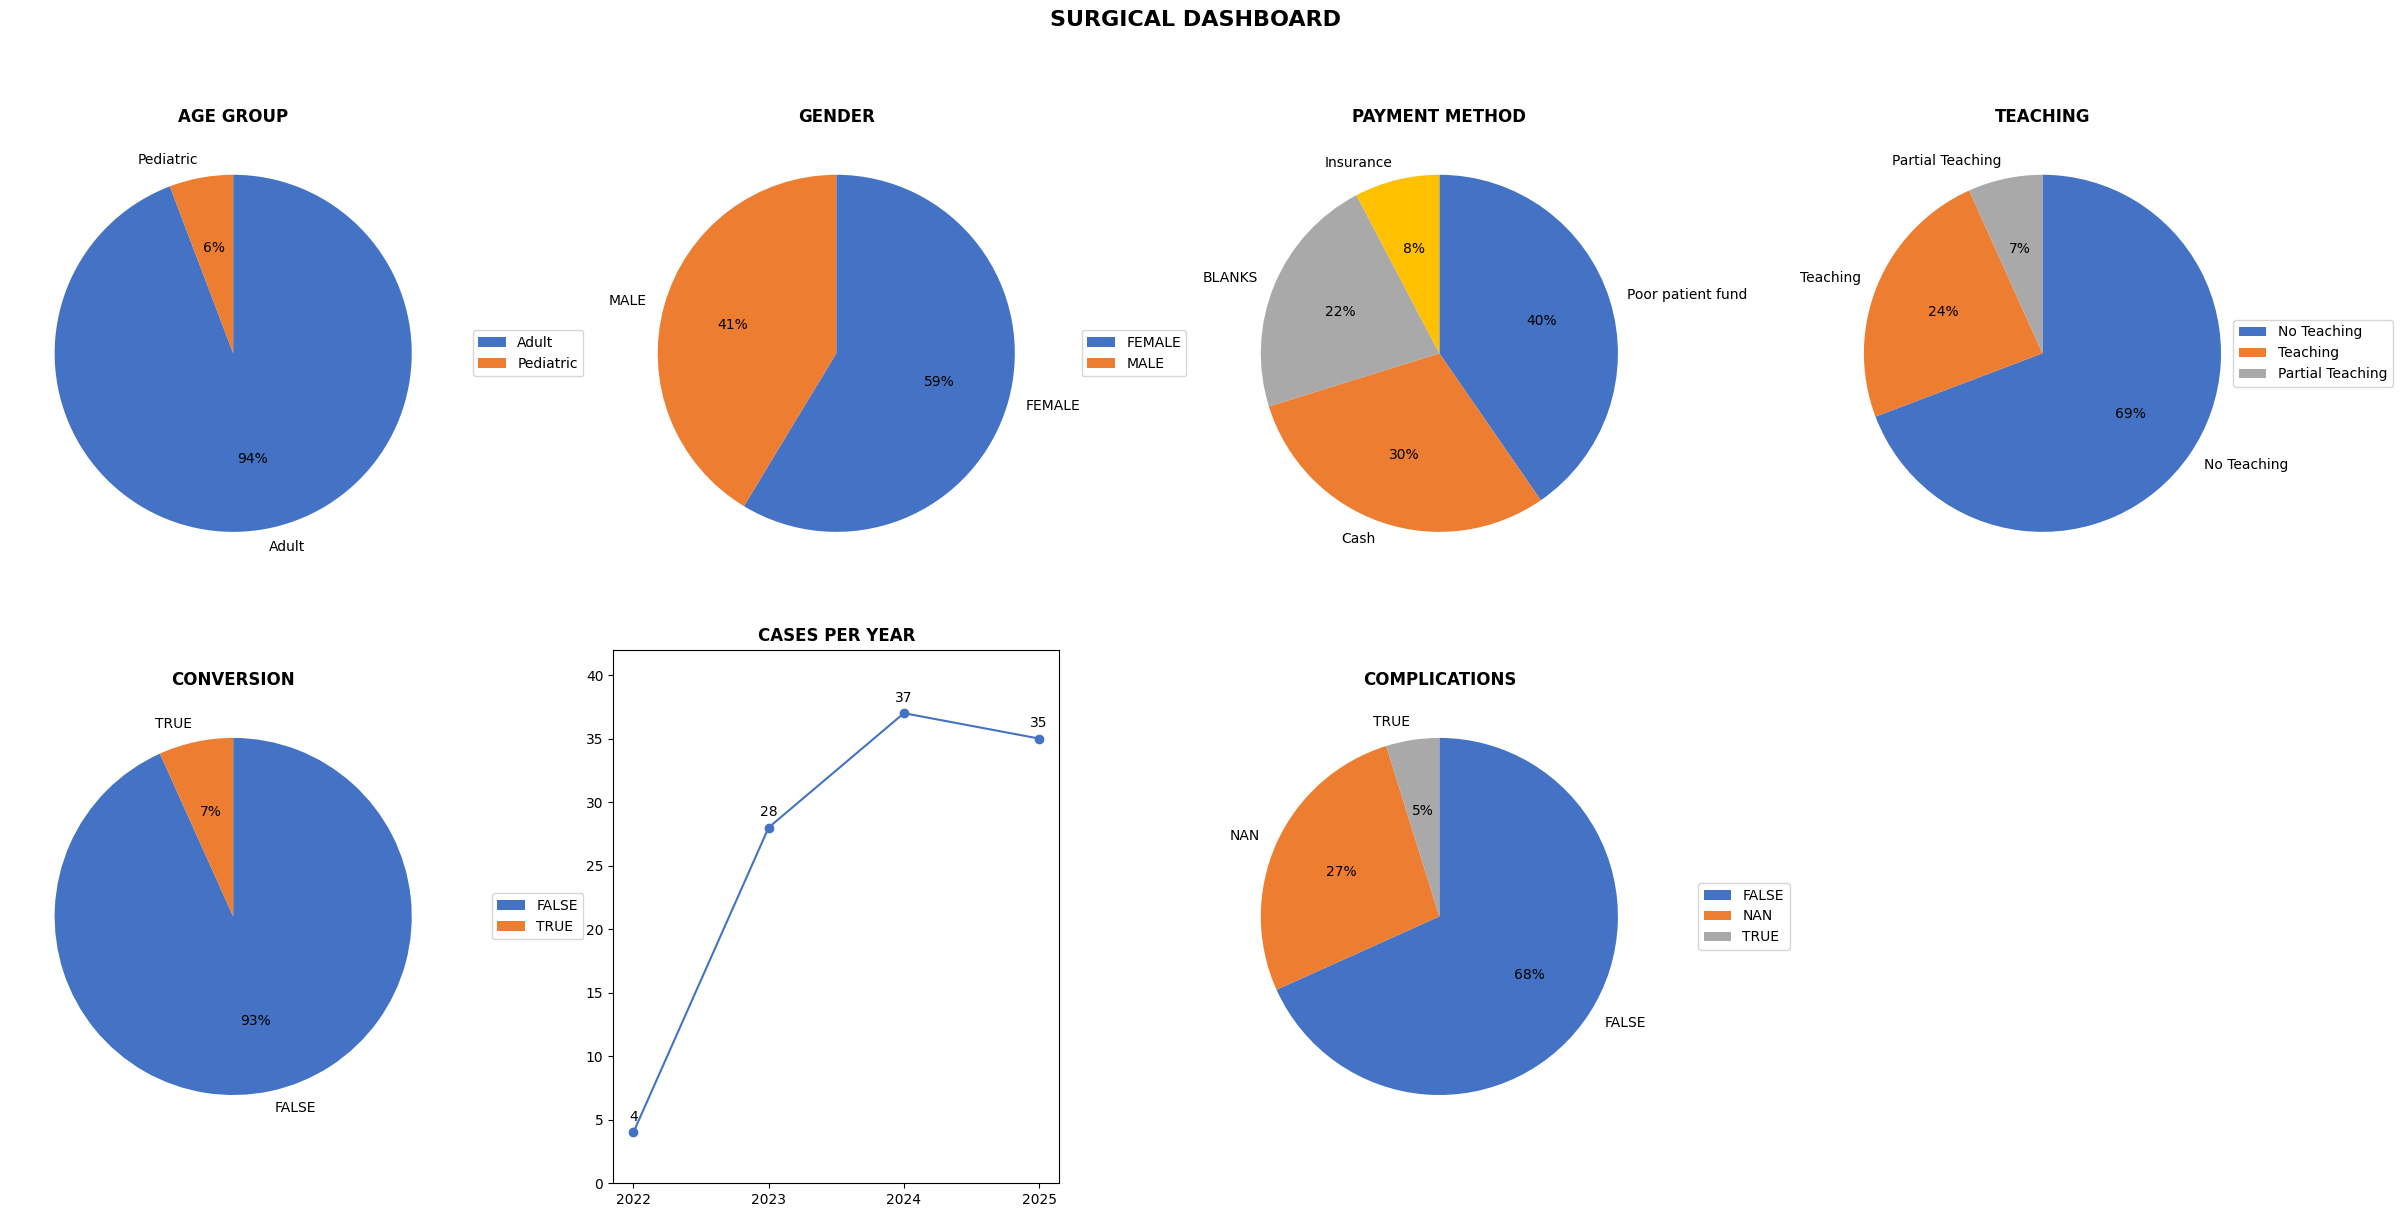

In [8]:
def plot_dashboard(df):
    COLORS = ["#4472C4", "#ED7D31", "#A9A9A9", "#FFC000", "#5B9BD5", "#70AD47"]
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    axes = axes.flatten()

    # --- AGE GROUP ---
    counts = df["age_group"].value_counts()
    axes[0].pie(counts, labels=counts.index, autopct="%1.0f%%",
                colors=COLORS, startangle=90, counterclock=False)
    axes[0].set_title("AGE GROUP", fontweight="bold")
    axes[0].legend(counts.index, loc="center right", bbox_to_anchor=(1.3, 0.5))

    # --- GENDER ---
    counts = df["sex"].value_counts()
    axes[1].pie(counts, labels=counts.index, autopct="%1.0f%%",
                colors=COLORS, startangle=90, counterclock=False)
    axes[1].set_title("GENDER", fontweight="bold")
    axes[1].legend(counts.index, loc="center right", bbox_to_anchor=(1.3, 0.5))

    # --- PAYMENT METHOD ---
    counts = df["payment_method_scheme_cash"].value_counts(dropna=False)
    counts.index = counts.index.fillna("BLANKS")
    axes[2].pie(counts, labels=counts.index, autopct="%1.0f%%",
                colors=COLORS, startangle=90, counterclock=False)
    axes[2].set_title("PAYMENT METHOD", fontweight="bold")

    # --- TEACHING CATEGORY ---
    counts = df["teaching_category"].value_counts(dropna=False)
    counts.index = counts.index.fillna("BLANKS")
    axes[3].pie(counts, labels=counts.index, autopct="%1.0f%%",
                colors=COLORS, startangle=90, counterclock=False)
    axes[3].set_title("TEACHING", fontweight="bold")
    axes[3].legend(counts.index, loc="center right", bbox_to_anchor=(1.3, 0.5))

    # --- CONVERSION ---
    counts = df["conversion"].astype(str).str.strip().str.upper().value_counts(dropna=False)
    counts.index = counts.index.fillna("BLANKS")
    axes[4].pie(counts, labels=counts.index, autopct="%1.0f%%",
                colors=COLORS, startangle=90, counterclock=False)
    axes[4].set_title("CONVERSION", fontweight="bold")
    axes[4].legend(counts.index, loc="center right", bbox_to_anchor=(1.3, 0.5))

    # --- CASES PER YEAR ---
    cases_per_year = pd.to_datetime(df["date_of_surgery"]).dt.year.value_counts().sort_index()
    axes[5].plot(cases_per_year.index, cases_per_year.values, marker="o", color="#4472C4")
    for x, y in zip(cases_per_year.index, cases_per_year.values):
        axes[5].annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
    axes[5].set_title("CASES PER YEAR", fontweight="bold")
    axes[5].set_xticks(cases_per_year.index)
    axes[5].set_ylim(0, cases_per_year.max() + 5)

    # --- COMPLICATIONS ---
    counts = df["complication"].astype(str).str.strip().str.upper().value_counts(dropna=False)
    counts.index = counts.index.fillna("BLANKS")
    axes[6].pie(counts, labels=counts.index, autopct="%1.0f%%",
                colors=COLORS, startangle=90, counterclock=False)
    axes[6].set_title("COMPLICATIONS", fontweight="bold")
    axes[6].legend(counts.index, loc="center right", bbox_to_anchor=(1.3, 0.5))

    # --- hide unused ---
    axes[7].set_visible(False)

    plt.suptitle("SURGICAL DASHBOARD", fontweight="bold", fontsize=16, y=1.01)
    plt.tight_layout()

    # ── Save full dashboard ───────────────────────────────────────────
    os.makedirs("laparoscopy_plots", exist_ok=True)
    fig.savefig("laparoscopy_plots/00_surgical_dashboard.png", dpi=150, bbox_inches='tight')

    # ── Save each subplot individually ───────────────────────────────
    subplot_titles = [
        "01_age_group", "02_gender", "03_payment_method", "04_teaching",
        "05_conversion", "06_cases_per_year", "07_complications",
    ]
    renderer = fig.canvas.get_renderer()
    for ax, title in zip(axes[:7], subplot_titles):  # skip axes[7] (hidden)
        extent = ax.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
        fig.savefig(f"laparoscopy_plots/{title}.png",
                    bbox_inches=extent.expanded(1.15, 1.2), dpi=150)

    plt.show()

plot_dashboard(df)

In [9]:
# Minimum of 50 percent is teaching

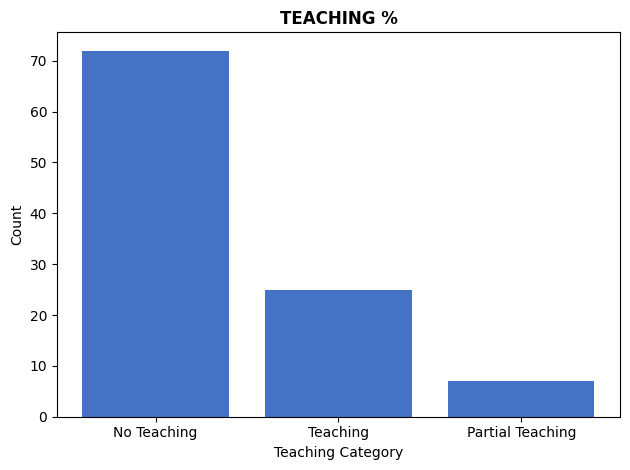

In [10]:
fig, ax = plt.subplots()
counts = df["teaching_category"].value_counts(dropna=False)
counts.index = counts.index.fillna("BLANKS")
ax.bar(counts.index.astype(str), counts.values, color="#4472C4")
ax.set_title("TEACHING %", fontweight="bold")
ax.set_xlabel("Teaching Category")
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig("laparoscopy_plots/08_teaching_category_bar.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
indication_map = {
    # Gallbladder / Biliary
    'Cholelithiasis': 'Gallbladder & Biliary',
    'Cholecystitis': 'Gallbladder & Biliary',
    'Acute/Chronic Cholecystitis': 'Gallbladder & Biliary',
    'Chronic Cholecystitis': 'Gallbladder & Biliary',
    'Biliary Pancreatitis': 'Gallbladder & Biliary',

    # Hernia
    'Bilateral Inguinal Hernia': 'Hernia',
    'Right Inguinal Hernia': 'Hernia',
    'Left Inguinal Hernia': 'Hernia',
    'Recurrent Right Inguinal Hernia': 'Hernia',
    'Incarcerated Left Inguinal Hernia': 'Hernia',
    'Bilateral Inguinal Hernia + Umbilical Hernia': 'Hernia',
    'Epigastric Hernia': 'Hernia',

    # Oncology
    'Carcinomatosis': 'Oncology',
    'Peritoneal Carcinomatosis': 'Oncology',
    'Rectal Tumour': 'Oncology',
    'Gist': 'Oncology',

    # Gynecology
    'R Ovarian Cyst': 'Gynecology',
    'Ovarian Cyst': 'Gynecology',
    'Ovarian Torsion': 'Gynecology',
    'R Hydrosalpinx': 'Gynecology',

    # Abdominal Pain / Unspecified
    'Ruq Pain': 'Abdominal Pain',
    'Rlq Pain': 'Abdominal Pain',
    'Chronic Abdominal Pain': 'Abdominal Pain',

    # Acute Abdomen
    'Appendicitis': 'Acute Abdomen',
    'Adhesions': 'Acute Abdomen',
    'Partial Bo': 'Acute Abdomen',  # Partial Bowel Obstruction
    'Stab Wound': 'Acute Abdomen',

    # Other
    'Undescended Testis': 'Other',
    'Liver Cyst': 'Other',
    'Esophageal Sclerosis': 'Other',
    'Patent Urachus': 'Other',
}

df["indication_group"] = df["indication"].map(indication_map)

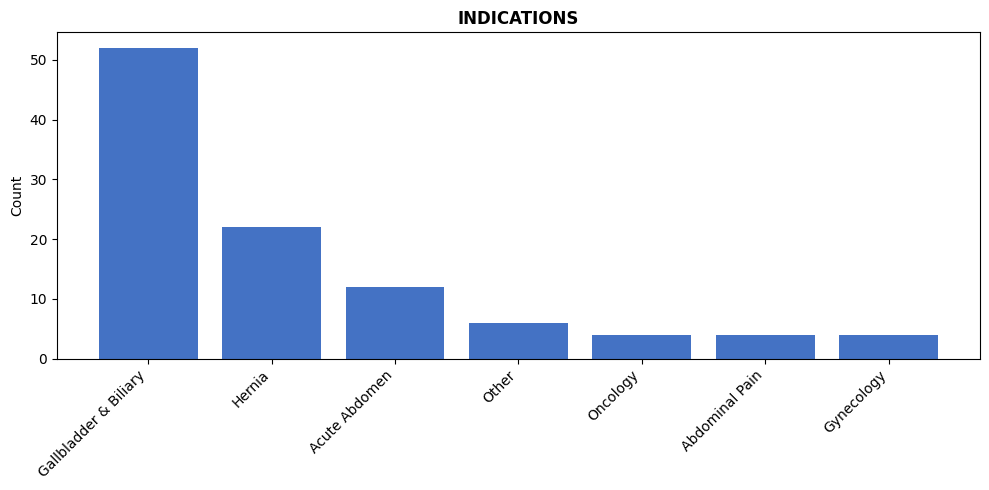

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
counts_ind = df["indication_group"].value_counts().sort_values(ascending=False)
ax.bar(counts_ind.index, counts_ind.values, color="#4472C4")
ax.set_title("INDICATIONS", fontweight="bold")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
fig.savefig("laparoscopy_plots/09_indications.png", dpi=150, bbox_inches='tight')
plt.show()

In [13]:
import pandas as pd

df_lap = df.copy()

# Quarter and teaching status
df_lap['quarter'] = pd.to_datetime(df_lap['date_of_surgery']).dt.to_period('Q').astype(str)
df_lap['is_teaching'] = df_lap['teaching_category'] != 'No Teaching'
df_lap['teaching_status'] = df_lap['is_teaching'].map({True: 'Teaching', False: 'Non-teaching'})

# Fix numeric columns
df_lap['duration_mins'] = pd.to_numeric(df_lap['duration_mins'], errors='coerce')
df_lap['amount_of_gas_used_l'] = pd.to_numeric(df_lap['amount_of_gas_used_l'], errors='coerce')

# Year
df_lap['year'] = pd.to_datetime(df_lap['date_of_surgery']).dt.year

# --- Metric cards ---
print("Total cases:", len(df_lap))
print("Teaching cases:", df_lap['is_teaching'].sum())
print("Avg duration (teaching):", df_lap[df_lap['is_teaching']]['duration_mins'].mean().round(1))
print("Avg duration (non-teaching):", df_lap[~df_lap['is_teaching']]['duration_mins'].mean().round(1))
print("Avg gas (teaching):", df_lap[df_lap['is_teaching']]['amount_of_gas_used_l'].mean().round(1))
print("Avg gas (non-teaching):", df_lap[~df_lap['is_teaching']]['amount_of_gas_used_l'].mean().round(1))

# --- By teaching category ---
print("\nCases by teaching category:")
print(df_lap.groupby('teaching_category').size())
print("\nAvg duration by teaching category:")
print(df_lap.groupby('teaching_category')['duration_mins'].mean().round(1))
print("\nAvg gas by teaching category:")
print(df_lap.groupby('teaching_category')['amount_of_gas_used_l'].mean().round(1))

# --- Teaching % per quarter ---
print("\nTeaching rate per quarter (%):")
print((df_lap.groupby('quarter')['is_teaching'].mean() * 100).round(1))

# --- Gas per quarter ---
print("\nAvg gas per quarter:")
print(df_lap.groupby('quarter')['amount_of_gas_used_l'].mean().round(1))

# --- Muscle relaxants ---
df_lap['muscle_relaxant_used'] = df_lap['muscle_relaxant_used'].str.strip().str.lower()
print("\nMuscle relaxant usage:")
print(df_lap['muscle_relaxant_used'].value_counts())
print("\nMuscle relaxant by year:")
print(df_lap.groupby(['year', 'muscle_relaxant_used']).size().unstack(fill_value=0))

Total cases: 104
Teaching cases: 32
Avg duration (teaching): 86.8
Avg duration (non-teaching): 98.3
Avg gas (teaching): 119.7
Avg gas (non-teaching): 131.3

Cases by teaching category:
teaching_category
No Teaching         72
Partial Teaching     7
Teaching            25
dtype: int64

Avg duration by teaching category:
teaching_category
No Teaching          98.3
Partial Teaching    118.4
Teaching             77.9
Name: duration_mins, dtype: Float64

Avg gas by teaching category:
teaching_category
No Teaching         131.3
Partial Teaching    209.7
Teaching             94.6
Name: amount_of_gas_used_l, dtype: float64

Teaching rate per quarter (%):
quarter
2022Q4     0.0
2023Q1     0.0
2023Q2     0.0
2023Q3    40.0
2023Q4     0.0
2024Q1    28.6
2024Q2    42.9
2024Q3    33.3
2024Q4    18.2
2025Q1    50.0
2025Q2     0.0
2025Q3    50.0
2025Q4    76.9
Name: is_teaching, dtype: float64

Avg gas per quarter:
quarter
2022Q4    102.8
2023Q1     92.6
2023Q2     67.0
2023Q3     74.8
2023Q4    152.

In [14]:
df.surgery_type.unique()

array(['Appendectomy', 'Cholecystectomy', 'TAPP',
       'Diagnostic laparoscopy', 'Hernia pediatric',
       'Liver cyst unroofing', 'Adhaesiolysis',
       'Laparoscopic feeding tube'], dtype=object)

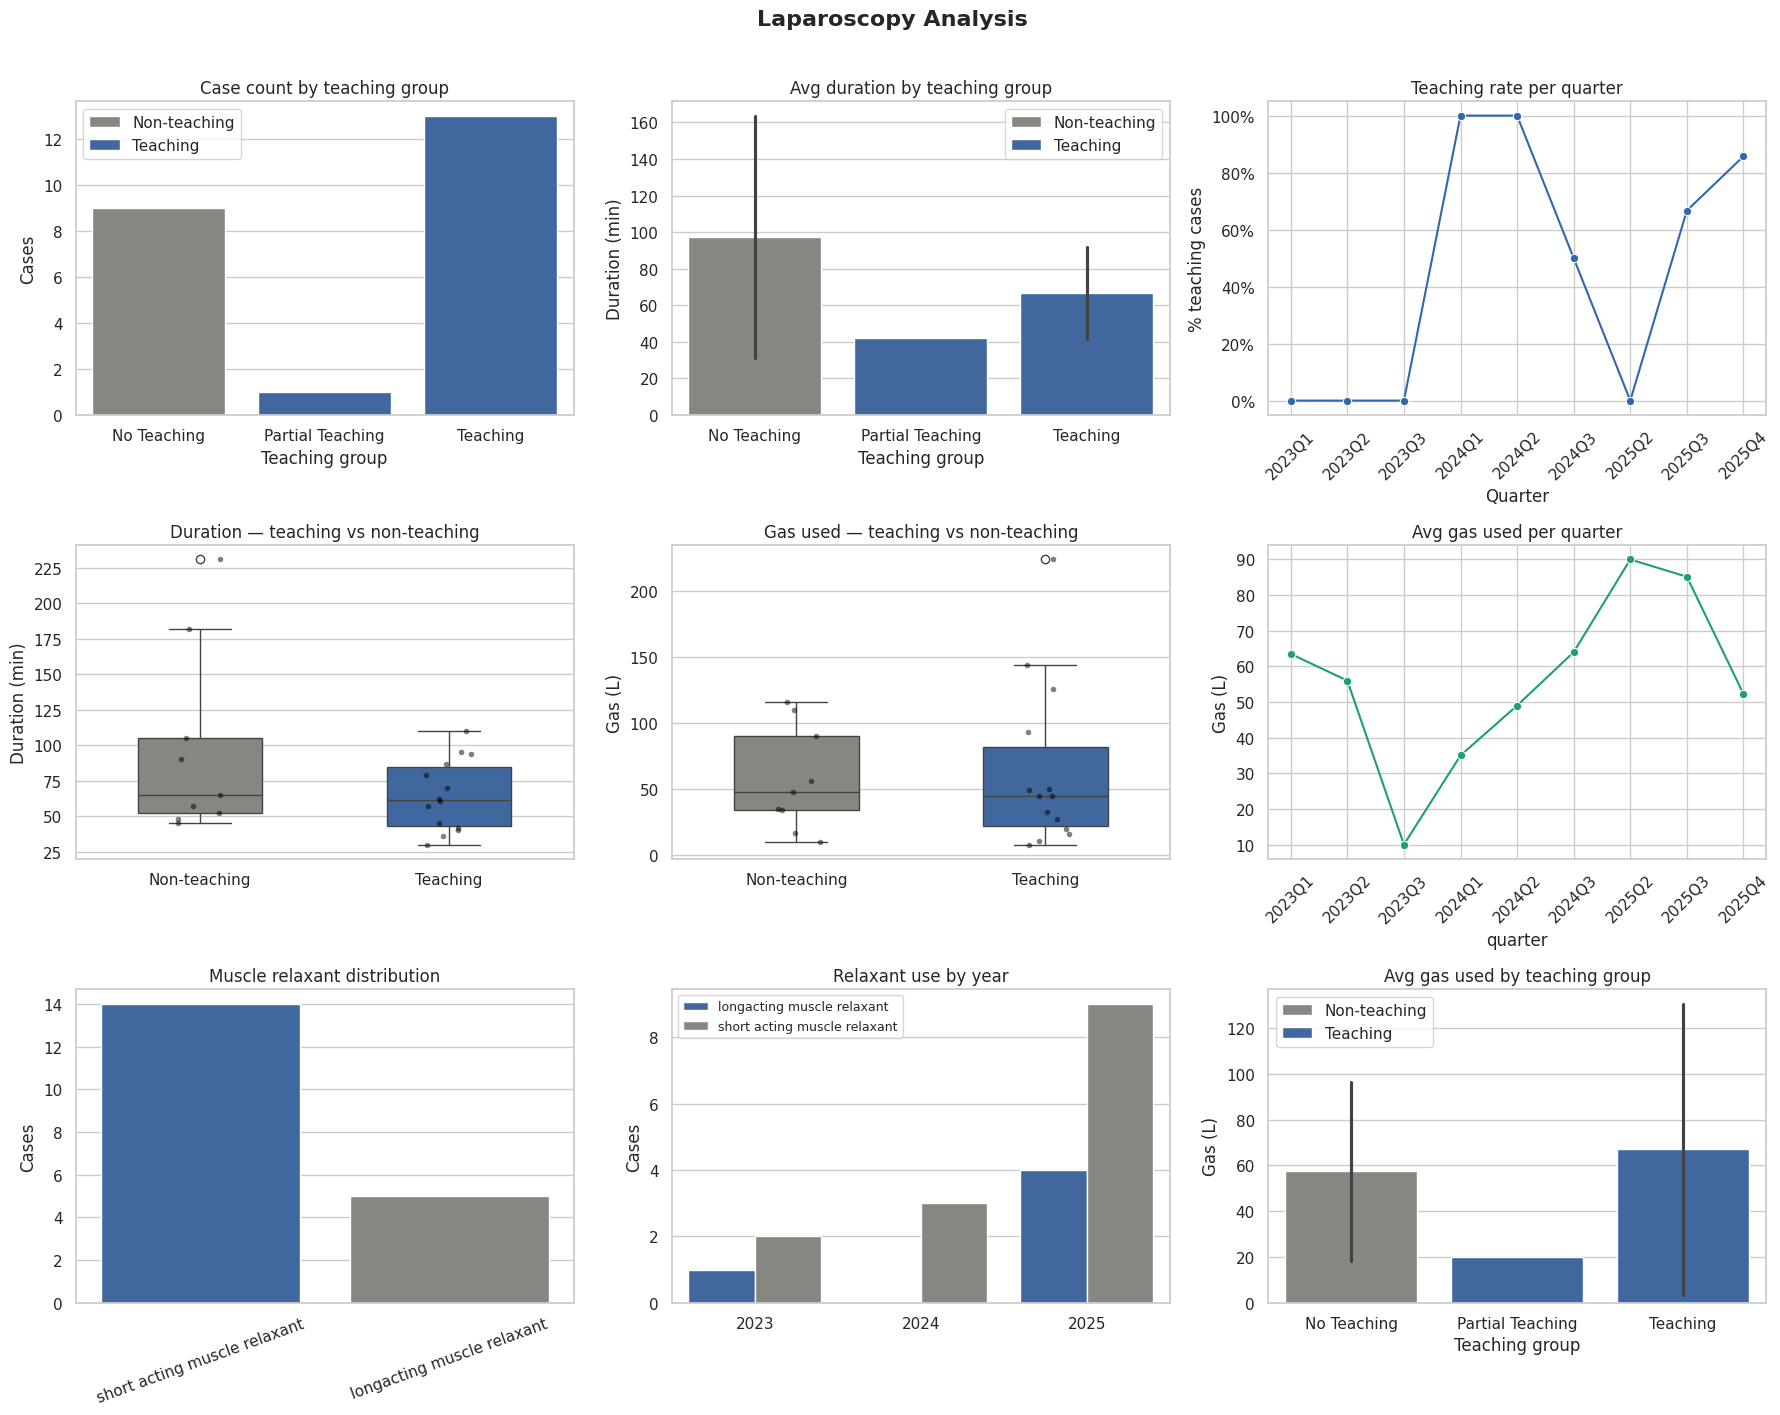

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# ── Setup ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Laparoscopy Analysis", fontsize=16, fontweight='bold', y=1.01)

GROUP_ORDER = ['No Teaching', 'Partial Teaching', 'Teaching']
BLUE, GRAY, TEAL, AMBER = '#3266ad', '#888780', '#1D9E75', '#c47d2e'

df_lap = df[df['surgery_type'].str.contains('laparoscop', case=False, na=False)].copy()
df_lap['quarter'] = pd.to_datetime(df_lap['date_of_surgery']).dt.to_period('Q').astype(str)
df_lap['year'] = pd.to_datetime(df_lap['date_of_surgery']).dt.year
df_lap['is_teaching'] = df_lap['teaching_category'] != 'No Teaching'
df_lap['teaching_status'] = df_lap['is_teaching'].map({True: 'Teaching', False: 'Non-teaching'})
df_lap['muscle_relaxant_used'] = df_lap['muscle_relaxant_used'].str.strip().str.lower()
df_lap['duration_mins'] = pd.to_numeric(df_lap['duration_mins'], errors='coerce')
df_lap['amount_of_gas_used_l'] = pd.to_numeric(df_lap['amount_of_gas_used_l'], errors='coerce')

# ── 1. Case count by teaching group ───────────────────────────────────
ax = axes[0, 0]
group_counts = df_lap.groupby(['teaching_category', 'teaching_status']).size().reset_index(name='Count')
sns.barplot(data=group_counts, x='teaching_category', y='Count',
            hue='teaching_status', order=GROUP_ORDER,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY}, ax=ax)
ax.set_title("Case count by teaching group")
ax.set_xlabel("Teaching group"); ax.set_ylabel("Cases")
ax.legend(title=None)

# ── 2. Duration by teaching group ─────────────────────────────────────
ax = axes[0, 1]
sns.barplot(data=df_lap, x='teaching_category', y='duration_mins',
            hue='teaching_status', order=GROUP_ORDER,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY},
            estimator='mean', errorbar='sd', ax=ax)
ax.set_title("Avg duration by teaching group")
ax.set_xlabel("Teaching group"); ax.set_ylabel("Duration (min)")
ax.legend(title=None)

# ── 3. Teaching % per quarter ──────────────────────────────────────────
ax = axes[0, 2]
q_teach = df_lap.groupby('quarter')['is_teaching'].mean().mul(100).reset_index()
q_teach.columns = ['Quarter', 'Teaching %']
sns.lineplot(data=q_teach, x='Quarter', y='Teaching %',
             marker='o', color=BLUE, ax=ax)
ax.set_title("Teaching rate per quarter")
ax.set_ylabel("% teaching cases")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', rotation=45)

# ── 4. Duration — teaching vs non-teaching ────────────────────────────
ax = axes[1, 0]
sns.boxplot(data=df_lap, x='teaching_status', y='duration_mins',
            hue='teaching_status', legend=False,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY},
            width=0.5, ax=ax)
sns.stripplot(data=df_lap, x='teaching_status', y='duration_mins',
              color='black', size=4, alpha=0.5, ax=ax)
ax.set_title("Duration — teaching vs non-teaching")
ax.set_xlabel(""); ax.set_ylabel("Duration (min)")

# ── 5. Gas used — teaching vs non-teaching ────────────────────────────
ax = axes[1, 1]
sns.boxplot(data=df_lap, x='teaching_status', y='amount_of_gas_used_l',
            hue='teaching_status', legend=False,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY},
            width=0.5, ax=ax)
sns.stripplot(data=df_lap, x='teaching_status', y='amount_of_gas_used_l',
              color='black', size=4, alpha=0.5, ax=ax)
ax.set_title("Gas used — teaching vs non-teaching")
ax.set_xlabel(""); ax.set_ylabel("Gas (L)")

# ── 6. Gas used per quarter ───────────────────────────────────────────
ax = axes[1, 2]
q_gas = df_lap.groupby('quarter')['amount_of_gas_used_l'].mean().reset_index()
sns.lineplot(data=q_gas, x='quarter', y='amount_of_gas_used_l',
             marker='o', color=TEAL, ax=ax)
ax.set_title("Avg gas used per quarter")
ax.set_ylabel("Gas (L)")
ax.tick_params(axis='x', rotation=45)

# ── 7. Muscle relaxant distribution ──────────────────────────────────
ax = axes[2, 0]
rel_counts = df_lap['muscle_relaxant_used'].value_counts().reset_index()
rel_counts.columns = ['Relaxant', 'Count']
colors = [BLUE, GRAY, AMBER, TEAL][:len(rel_counts)]
sns.barplot(data=rel_counts, x='Relaxant', y='Count',
            hue='Relaxant', legend=False,
            palette=dict(zip(rel_counts['Relaxant'], colors)), ax=ax)
ax.set_title("Muscle relaxant distribution")
ax.set_xlabel(""); ax.set_ylabel("Cases")
ax.tick_params(axis='x', rotation=20)

# ── 8. Relaxant use by year ───────────────────────────────────────────
ax = axes[2, 1]
rel_year = df_lap.groupby(['year', 'muscle_relaxant_used']).size().reset_index(name='Count')
relaxant_types = rel_year['muscle_relaxant_used'].unique()
rel_palette = dict(zip(relaxant_types, [BLUE, GRAY, AMBER, TEAL][:len(relaxant_types)]))
sns.barplot(data=rel_year, x='year', y='Count',
            hue='muscle_relaxant_used',
            palette=rel_palette, ax=ax)
ax.set_title("Relaxant use by year")
ax.set_xlabel(""); ax.set_ylabel("Cases")
ax.legend(title=None, fontsize=9)

# ── 9. Gas used by teaching group ────────────────────────────────────
ax = axes[2, 2]
sns.barplot(data=df_lap, x='teaching_category', y='amount_of_gas_used_l',
            hue='teaching_status', order=GROUP_ORDER,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY},
            estimator='mean', errorbar='sd', ax=ax)
ax.set_title("Avg gas used by teaching group")
ax.set_xlabel("Teaching group"); ax.set_ylabel("Gas (L)")
ax.legend(title=None)

# ── Final layout ──────────────────────────────────────────────────────
plt.tight_layout()
# Save each subplot individually
subplot_titles = [
    "01_case_count_by_teaching_group",
    "02_avg_duration_by_teaching_group",
    "03_teaching_rate_per_quarter",
    "04_duration_teaching_vs_nonteaching",
    "05_gas_used_teaching_vs_nonteaching",
    "06_avg_gas_per_quarter",
    "07_muscle_relaxant_distribution",
    "08_relaxant_use_by_year",
    "09_avg_gas_by_teaching_group",
]

for ax, title in zip(axes.flat, subplot_titles):
    extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(f"laparoscopy_plots/{title}.png", bbox_inches=extent.expanded(1.1, 1.2), dpi=150)
plt.show()

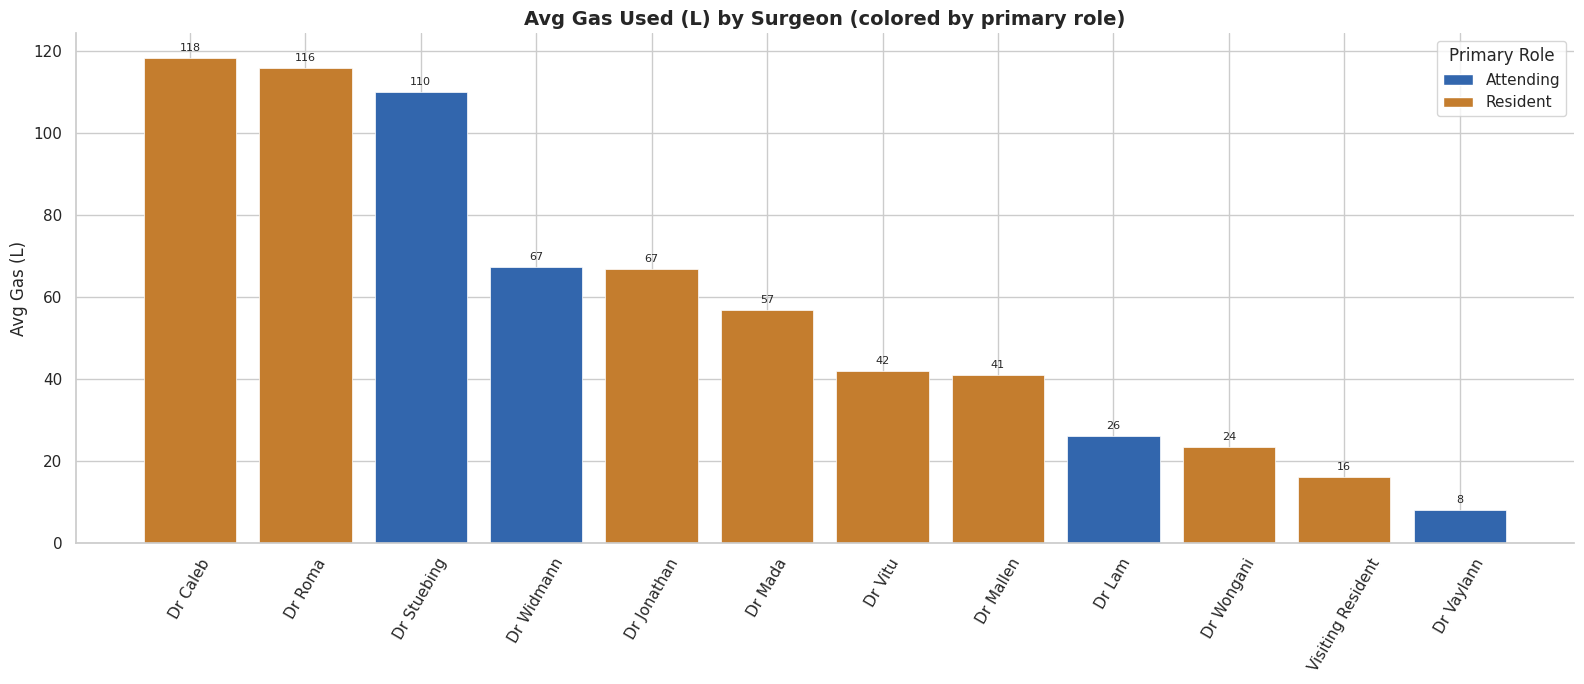

In [16]:
priority = ['attending_surgeon_1', 'attending_surgeon_2',
            'resident_surgeon_1', 'resident_surgeon_2']
role_labels = {
    'attending_surgeon_1': 'Attending',
    'attending_surgeon_2': 'Attending',
    'resident_surgeon_1': 'Resident',
    'resident_surgeon_2': 'Resident'
}
role_colors = {
    'attending_surgeon_1': BLUE,
    'attending_surgeon_2': BLUE,
    'resident_surgeon_1': AMBER,
    'resident_surgeon_2': AMBER
}

all_data = []
for col in priority:
    temp = (df_lap.groupby(col)['amount_of_gas_used_l']
                  .mean().dropna().reset_index())
    temp.columns = ['Surgeon', 'Avg Gas (L)']
    # Drop blank/NaN surgeon names
    temp = temp[temp['Surgeon'].str.strip().str.len() > 0]
    temp['Role'] = role_labels[col]
    temp['Color'] = role_colors[col]
    all_data.append(temp)

combined = pd.concat(all_data).drop_duplicates(subset='Surgeon', keep='first')
combined = combined.sort_values('Avg Gas (L)', ascending=False)

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(combined['Surgeon'], combined['Avg Gas (L)'],
              color=combined['Color'], edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.annotate(f'{bar.get_height():.0f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                textcoords="offset points", xytext=(0, 5),
                ha='center', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=BLUE,  label='Attending'),
    Patch(facecolor=AMBER, label='Resident')
]
ax.legend(handles=legend_elements, title="Primary Role", loc='upper right')
ax.set_title("Avg Gas Used (L) by Surgeon (colored by primary role)",
             fontweight='bold', fontsize=14)
ax.set_ylabel("Avg Gas (L)")
ax.tick_params(axis='x', rotation=60)
sns.despine()
plt.tight_layout()
plt.savefig("laparoscopy_plots/10_gas_by_surgeon_combined.png", dpi=150, bbox_inches='tight')
plt.show()

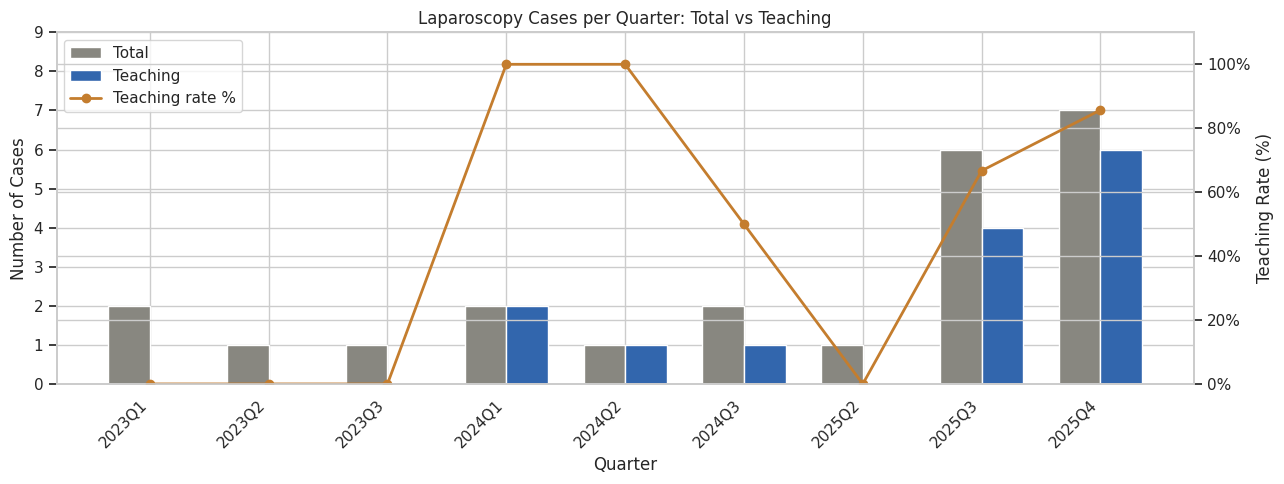

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Prep
df_lap = df[df['surgery_type'].str.contains('laparoscop', case=False, na=False)].copy()
df_lap['quarter'] = pd.to_datetime(df_lap['date_of_surgery']).dt.to_period('Q').astype(str)
df_lap['is_teaching'] = df_lap['teaching_category'] != 'No Teaching'

# Aggregate
q = df_lap.groupby('quarter').agg(
    Total=('is_teaching', 'count'),
    Teaching=('is_teaching', 'sum')
).reset_index()
q['Teaching %'] = (q['Teaching'] / q['Total'] * 100).round(1)

quarters = q['quarter'].tolist()
x = range(len(quarters))
bar_width = 0.35

# Plot
fig, ax1 = plt.subplots(figsize=(13, 5))

# Side-by-side bars
bars1 = ax1.bar([i - bar_width/2 for i in x], q['Total'],
                width=bar_width, color='#888780', label='Total')
bars2 = ax1.bar([i + bar_width/2 for i in x], q['Teaching'],
                width=bar_width, color='#3266ad', label='Teaching')

ax1.set_xticks(list(x))
ax1.set_xticklabels(quarters, rotation=45, ha='right')
ax1.set_xlabel("Quarter")
ax1.set_ylabel("Number of Cases")
ax1.set_ylim(0, max(q['Total'].max(), q['Teaching'].max()) + 2)

# Teaching rate line on secondary axis
ax2 = ax1.twinx()
ax2.plot(list(x), q['Teaching %'], color='#c47d2e',
         marker='o', linewidth=2, label='Teaching rate %')
ax2.set_ylabel("Teaching Rate (%)")
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

# Combined legend
lines, labels = ax2.get_legend_handles_labels()
bars, bar_labels = ax1.get_legend_handles_labels()
ax1.legend(bars + lines, bar_labels + labels, loc='upper left')

plt.title("Laparoscopy Cases per Quarter: Total vs Teaching")
plt.tight_layout()
plt.savefig("laparoscopy_plots/11_teaching_rate_per_quarter.png", dpi=150, bbox_inches='tight')
plt.show()

In [18]:
df

,hospital_number,name,village_of_residence,sex,age_at_surgery,weight_kg,ward,previous_abdominal_surgery_yes_no,date_of_surgery,type_of_surgery,...,conversion,reason_of_conversion,time_of_conversion_min_after_incision,complication,complication_clavien_dindo,complication_description,surgery_type,age_group,teaching_category,indication_group
0,339284,Alex Chitandale,Malengachanza,MALE,28,NaN,SW,NO,2022-10-20,AE,...,False,NaN,<NA>,False,NaN,NaN,Appendectomy,Adult,No Teaching,Acute Abdomen
1,<NA>,Lifinet Kapichi,Mapiko,FEMALE,57,NaN,SW,NO,2022-11-17,CHE,...,False,NaN,<NA>,NaN,NaN,NaN,Cholecystectomy,Adult,No Teaching,Gallbladder & Biliary
2,341101,Annie Pheratu,Area 23,FEMALE,38,NaN,SW,NO,2022-11-24,CHE,...,False,NaN,<NA>,NaN,NaN,NaN,Cholecystectomy,Adult,No Teaching,Gallbladder & Biliary
3,345144,Chrissy Nkanasi,Kalolo,FEMALE,54,NaN,SW,NO,2022-12-28,CHE,...,False,NaN,<NA>,NaN,NaN,NaN,Cholecystectomy,Adult,No Teaching,Gallbladder & Biliary
4,344747,Brown Kapoloma,Kalosa,MALE,62,NaN,SW,NO,2023-01-26,CHE 1 open prostatectomy,...,False,NaN,<NA>,False,NaN,NaN,Cholecystectomy,Adult,No Teaching,Gallbladder & Biliary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,31248,Asiyatu Allan,Dedza,FEMALE,41,NaN,SW,NO,2025-11-12,"laparoscopic cholecystectomy, chronic cholecys...",...,False,NaN,<NA>,False,NaN,NaN,Cholecystectomy,Adult,No Teaching,Gallbladder & Biliary
100,<NA>,Marrium Lori,Lilongwe,FEMALE,16,NaN,SW,NO,2025-11-18,"diagn. lsc. Urachus resection, 16yo. patent ur...",...,False,NaN,<NA>,False,NaN,NaN,Diagnostic laparoscopy,Adult,Teaching,Other
101,31956,Grace Chipole,Lilongwe,FEMALE,47,NaN,PVT,NO,2025-11-19,"laparoscopic cholecystectomy, sympt cholecysto...",...,False,NaN,<NA>,False,NaN,NaN,Cholecystectomy,Adult,Teaching,Gallbladder & Biliary
102,32499,Fatima Lack,Lilongwe,FEMALE,32,NaN,SW,NO,2025-11-27,"laparoscopic r. adnexectomy, ovarian torsion",...,False,NaN,<NA>,False,NaN,NaN,Diagnostic laparoscopy,Adult,Teaching,Gynecology


In [19]:
df.to_excel('laparoscopy_cleaned.xlsx', index=False)